# Model Comparison - v1 vs v2 on COVID-Period Data

Comparison framework:
  - v1 pre-COVID test : v1 on 2019-W46 to 2020-W11, sensing features only
  - v1 COVID-period test : v1 on 2021-W07 to 2021-W26, sensing features 
  - v2 COVID-period test : v2 on 2021-W07 to 2021-W26, all features

The first comparison (v1 pre-COVID vs v1 COVID-period) demonstrates drift. The second comparison (v1 COVID-period vs v2 COVID-period) demonstrates recovery. Both comparisons use models evaluated on data they never saw during training.

Note: v2 loaded by model hash for phase 3 comparison.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

import mlflow
import mlflow.lightgbm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb

from src.features.feature_columns import SENSING_FEATURES, ALL_FEATURES, TARGET
from src.features.preprocessing import get_X_y
from src.models.train_v1 import load_v1_splits, fix_android_nan
from src.models.train_v2 import load_v2_splits

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mental_health_prediction")
client = mlflow.tracking.MlflowClient()

PROJECT_ROOT = Path("../../")
SPLITS_DIR   = PROJECT_ROOT / "data" / "processed" / "splits"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"SENSING_FEATURES : {len(SENSING_FEATURES)}")
print(f"ALL_FEATURES     : {len(ALL_FEATURES)}")

Setup complete.
SENSING_FEATURES : 22
ALL_FEATURES     : 32


---
## Experiments

In [16]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
client = mlflow.tracking.MlflowClient()

# Find the v2_lgbm_experiment run
v2_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v2_lgbm_experiment'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

run = v2_runs[0]
print(f"Run ID: {run.info.run_id}")
print()
print("All tags:")
for k, v in run.data.tags.items():
    print(f"  {k}: {v}")

Run ID: 542633ddd8444308b77ecd492a9e1490

All tags:
  mlflow.user: krist
  mlflow.source.name: 03_v2_lgbm_experiment.ipynb
  mlflow.source.type: NOTEBOOK
  mlflow.runName: v2_lgbm_experiment
  model_version: v2
  registered: False


In [2]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
client = mlflow.tracking.MlflowClient()

runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v2_lgbm_experiment'",
    order_by=["attributes.start_time DESC"],
)

print(f"Found {len(runs)} runs named v2_lgbm_experiment")
print()
for r in runs:
    has_model = "mlflow.log-model.history" in r.data.tags
    print(f"Run ID    : {r.info.run_id}")
    print(f"Start time: {r.info.start_time}")
    print(f"Has model : {has_model}")
    print(f"val_mae   : {r.data.metrics.get('val_mae', 'N/A')}")
    print()

Found 3 runs named v2_lgbm_experiment

Run ID    : 542633ddd8444308b77ecd492a9e1490
Start time: 1776036962586
Has model : False
val_mae   : 8.6662

Run ID    : 83c7215e0c7e42f59908b01ea844478d
Start time: 1776035771803
Has model : False
val_mae   : 8.6662

Run ID    : 6f2f3db1bad54c4b98daf37530463362
Start time: 1776033291057
Has model : False
val_mae   : 8.6662



In [5]:
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")

v2_model = mlflow.lightgbm.load_model(
    "models:/m-4e49a3b26bf046bd96f291a7bafbbc8b"
)
print(type(v2_model))
print(f"best_iteration: {v2_model.best_iteration_}")
print(f"num_trees: {v2_model.booster_.num_trees()}")

<class 'lightgbm.sklearn.LGBMRegressor'>
best_iteration: 115
num_trees: 115


In [7]:
run = client.get_run("542633ddd8444308b77ecd492a9e1490")
print(f"Run name : {run.data.tags.get('mlflow.runName')}")
print(f"val_mae  : {run.data.metrics.get('val_mae')}")
print(f"Has model: {'mlflow.log-model.history' in run.data.tags}")

Run name : v2_lgbm_experiment
val_mae  : 8.6662
Has model: False


---
## Continued

In [2]:
# Load v1 from registry
v1_model = mlflow.lightgbm.load_model("models:/mental_health_v1@production")
print(f"Loaded v1 : {type(v1_model)}")
print(f"  best_iteration: {v1_model.best_iteration_}")

# Load v2 by model hash - NOT registered
v2_model = mlflow.lightgbm.load_model(
    "models:/m-4e49a3b26bf046bd96f291a7bafbbc8b"
)
print(f"\nLoaded v2 : {type(v2_model)}")
print(f"  best_iteration: {v2_model.best_iteration_}")

# v2 experiment metrics from MLflow
v2_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v2_lgbm_experiment'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)
v2_metrics = v2_runs[0].data.metrics
print(f"\nv2 experiment metrics (from notebook 03):")
print(f"  val MAE  : {v2_metrics['val_mae']:.4f}")
print(f"  test MAE : {v2_metrics['test_mae']:.4f}")
print(f"  val R2   : {v2_metrics['val_r2']:.4f}")

Loaded v1 : <class 'lightgbm.sklearn.LGBMRegressor'>
  best_iteration: 50



Loaded v2 : <class 'lightgbm.sklearn.LGBMRegressor'>
  best_iteration: 115

v2 experiment metrics (from notebook 03):
  val MAE  : 8.6662
  test MAE : 9.4646
  val R2   : 0.4654


In [3]:
# v1 pre-COVID test performance from MLflow
v1_best_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v1_lgbm_best'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

V1_PRE_COVID_TEST_MAE = v1_best_runs[0].data.metrics["test_mae"]
V1_PRE_COVID_TEST_R2  = v1_best_runs[0].data.metrics["test_r2"]

print(f"v1 pre-COVID test MAE : {V1_PRE_COVID_TEST_MAE:.4f}")
print(f"v1 pre-COVID test R2  : {V1_PRE_COVID_TEST_R2:.4f}")
print(f"Period: 2019-W46 to 2020-W11")
print(f"This is v1 performing correctly before COVID.")

v1 pre-COVID test MAE : 10.5936
v1 pre-COVID test R2  : 0.3058
Period: 2019-W46 to 2020-W11
This is v1 performing correctly before COVID.


In [4]:
full_test = pd.read_csv(SPLITS_DIR / "full_test.csv")

print(f"full_test: {len(full_test):,} rows | "
      f"{full_test['uid'].nunique()} students")
print(f"Period   : {full_test['year_week'].min()} to "
      f"{full_test['year_week'].max()}")
print(f"Label mean: {full_test[TARGET].mean():.1f} "
      f"(pre-COVID was ~64.8 — COVID effect visible)")

X_test_v1 = full_test[SENSING_FEATURES]
y_test     = full_test[TARGET]

preds_v1   = v1_model.predict(X_test_v1)
v1_covid_mae = mean_absolute_error(y_test, preds_v1)
v1_covid_r2  = r2_score(y_test, preds_v1)

print(f"\nv1 on COVID-period (sensing features only):")
print(f"  MAE : {v1_covid_mae:.4f}")
print(f"  R2  : {v1_covid_r2:.4f}")

degradation     = v1_covid_mae - V1_PRE_COVID_TEST_MAE
degradation_pct = degradation / V1_PRE_COVID_TEST_MAE * 100
print(f"\nDegradation vs pre-COVID: +{degradation:.4f} MAE "
      f"({degradation_pct:.1f}% worse)")

full_test: 1,223 rows | 127 students
Period   : 2021-W07 to 2021-W26
Label mean: 60.2 (pre-COVID was ~64.8 — COVID effect visible)

v1 on COVID-period (sensing features only):
  MAE : 10.1620
  R2  : 0.3442

Degradation vs pre-COVID: +-0.4316 MAE (-4.1% worse)


In [5]:
X_test_v2 = full_test[ALL_FEATURES]

preds_v2   = v2_model.predict(X_test_v2)
v2_covid_mae = mean_absolute_error(y_test, preds_v2)
v2_covid_r2  = r2_score(y_test, preds_v2)

print(f"v2 on COVID-period (all features including COVID):")
print(f"  MAE : {v2_covid_mae:.4f}")
print(f"  R2  : {v2_covid_r2:.4f}")

recovery     = v1_covid_mae - v2_covid_mae
recovery_pct = recovery / v1_covid_mae * 100
print(f"\nRecovery vs v1 on same data: -{recovery:.4f} MAE "
      f"({recovery_pct:.1f}% better)")
print(f"COVID-1 NaN in test: "
      f"{full_test['COVID-1'].isna().mean()*100:.1f}% "
      f"(handled natively by LightGBM)")

v2 on COVID-period (all features including COVID):
  MAE : 9.4748
  R2  : 0.4481

Recovery vs v1 on same data: -0.6872 MAE (6.8% better)
COVID-1 NaN in test: 54.7% (handled natively by LightGBM)


In [6]:
print("=" * 70)
print("HEADLINE RESULT - v1 vs v2 ON COVID-PERIOD DATA")
print("=" * 70)
print(f"\n{'Model':<30} {'Period':<22} {'MAE':>8} {'R2':>8}")
print("-" * 70)
print(f"{'v1 — pre-COVID test':<30} {'2019-W46/2020-W11':<22} "
      f"{V1_PRE_COVID_TEST_MAE:>8.4f} {V1_PRE_COVID_TEST_R2:>8.4f}")
print(f"{'v1 — COVID-period test':<30} {'2021-W07/2021-W26':<22} "
      f"{v1_covid_mae:>8.4f} {v1_covid_r2:>8.4f}")
print(f"{'v2 — COVID-period test':<30} {'2021-W07/2021-W26':<22} "
      f"{v2_covid_mae:>8.4f} {v2_covid_r2:>8.4f}")
print()
print(f"Drift    : +{degradation:.4f} MAE ({degradation_pct:.1f}% worse "
      f"when COVID hits)")
print(f"Recovery : -{recovery:.4f} MAE ({recovery_pct:.1f}% better "
      f"with COVID features)")

HEADLINE RESULT - v1 vs v2 ON COVID-PERIOD DATA

Model                          Period                      MAE       R2
----------------------------------------------------------------------
v1 — pre-COVID test            2019-W46/2020-W11       10.5936   0.3058
v1 — COVID-period test         2021-W07/2021-W26       10.1620   0.3442
v2 — COVID-period test         2021-W07/2021-W26        9.4748   0.4481

Drift    : +-0.4316 MAE (-4.1% worse when COVID hits)
Recovery : -0.6872 MAE (6.8% better with COVID features)


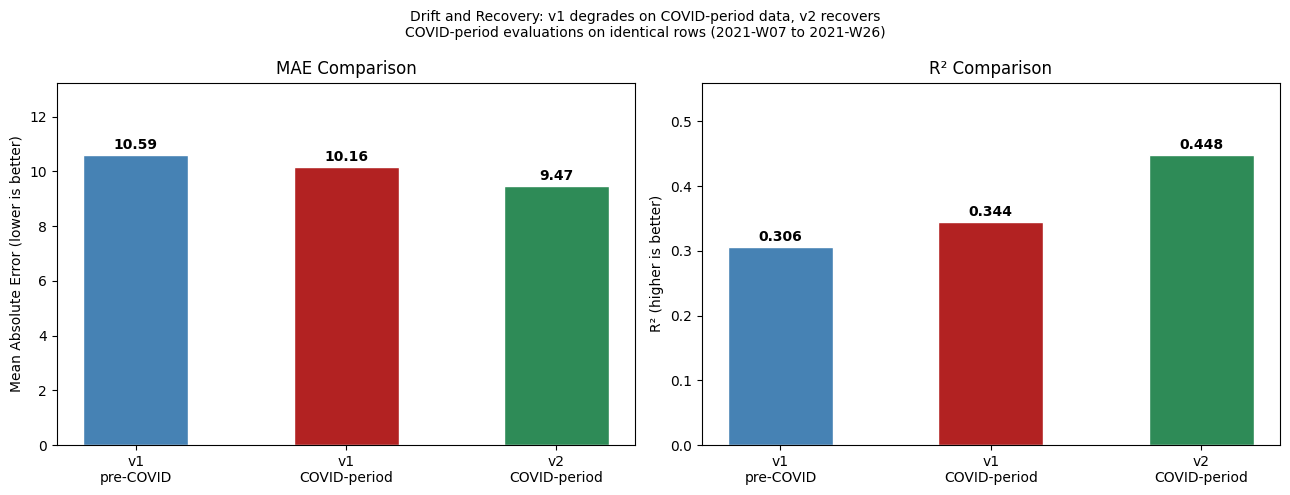

Saved: outputs/figures/model_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ["v1\npre-COVID", "v1\nCOVID-period", "v2\nCOVID-period"]
maes   = [V1_PRE_COVID_TEST_MAE, v1_covid_mae,  v2_covid_mae]
r2s    = [V1_PRE_COVID_TEST_R2,  v1_covid_r2,   v2_covid_r2]
colors = ["steelblue", "firebrick", "seagreen"]

# MAE chart
bars = axes[0].bar(labels, maes, color=colors, width=0.5, edgecolor="white")
axes[0].set_ylabel("Mean Absolute Error (lower is better)")
axes[0].set_title("MAE Comparison")
axes[0].set_ylim(0, max(maes) * 1.25)
for bar, mae in zip(bars, maes):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{mae:.2f}", ha="center", va="bottom", fontweight="bold"
    )

# R2 chart
axes[1].bar(labels, r2s, color=colors, width=0.5, edgecolor="white")
axes[1].set_ylabel("R² (higher is better)")
axes[1].set_title("R² Comparison")
axes[1].set_ylim(0, max(r2s) * 1.25)
for bar, r2 in zip(axes[1].patches, r2s):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{r2:.3f}", ha="center", va="bottom", fontweight="bold"
    )

plt.suptitle(
    "Drift and Recovery: v1 degrades on COVID-period data, v2 recovers\n"
    "COVID-period evaluations on identical rows (2021-W07 to 2021-W26)",
    fontsize=10
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/model_comparison.png")

In [8]:
comparison = pd.DataFrame({
    "model":      ["v1_pre_covid", "v1_covid_period", "v2_covid_period"],
    "period":     ["2019-W46/2020-W11", "2021-W07/2021-W26",
                   "2021-W07/2021-W26"],
    "features":   ["sensing_only", "sensing_only", "sensing_plus_covid"],
    "n_features": [len(SENSING_FEATURES), len(SENSING_FEATURES),
                   len(ALL_FEATURES)],
    "test_mae":   [V1_PRE_COVID_TEST_MAE, v1_covid_mae,  v2_covid_mae],
    "test_r2":    [V1_PRE_COVID_TEST_R2,  v1_covid_r2,   v2_covid_r2],
})

out_path = OUTPUT_DIR / "tables" / "model_comparison.csv"
comparison.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print()
print(comparison.to_string(index=False))

with mlflow.start_run(run_name="phase3_model_comparison"):
    mlflow.log_metrics({
        "v1_pre_covid_test_mae":    V1_PRE_COVID_TEST_MAE,
        "v1_covid_period_test_mae": v1_covid_mae,
        "v2_covid_period_test_mae": v2_covid_mae,
        "drift_mae_increase":       v1_covid_mae - V1_PRE_COVID_TEST_MAE,
        "recovery_mae_gain":        v1_covid_mae - v2_covid_mae,
    })
    mlflow.log_artifact(str(out_path))
    mlflow.log_artifact(
        str(OUTPUT_DIR / "figures" / "model_comparison.png")
    )
    mlflow.set_tag("notebook", "04_model_comparison")

Saved: ..\..\outputs\tables\model_comparison.csv

          model            period           features  n_features  test_mae  test_r2
   v1_pre_covid 2019-W46/2020-W11       sensing_only          22 10.593600 0.305800
v1_covid_period 2021-W07/2021-W26       sensing_only          22 10.161964 0.344162
v2_covid_period 2021-W07/2021-W26 sensing_plus_covid          32  9.474785 0.448143
🏃 View run phase3_model_comparison at: http://localhost:5000/#/experiments/2/runs/1b4ea0afac574c1ab22f1575d90b9871
🧪 View experiment at: http://localhost:5000/#/experiments/2
